## RQ8: How does the venue capacity influence the win rate of the away team?

- https://v3.football.api-sports.io
- for all venues
- venue capacity /venues?country=Germany ['response'] [posit.] ['capacity']
- venue city /venues?country=Germany ['response'] [posit.] ['city']

In [105]:
import requests
import matplotlib.pyplot as plt

In [106]:
from requests.auth import HTTPBasicAuth
header = {'x-apisports-key': 'dfb3ecf3de2f46a60337771460282483'}

In [107]:
# teamID_football.api: teamID_api.openliga
# no venue for Schalke teamid 9, Herta teamid 54, Köln teamid 65, Darmstadt teamid 118
teamIDmapper = {
    '157': 40,      # München
    '160': 112,     # Freiburg
    '161': 131,     # Wolfsburg
    '162': 134,     # Bremen
    '163': 87,      # Mönchengladbach
    '164': 81,      # Mainz
    '165': 7,       # Dortmund
    '167': 175,     # Hoffenheim
    '168': 6,       # Leverkusen
    '169': 91,      # Frankfurt
    '170': 95,      # Augsburg
    '172': 16,      # Stuttgart
    '173': 1635,    # Leipzig
    '176': 129,     # Bochum
    '180': 199,     # Heidenheim
    '182': 80,      # Union Berlin
    '186': 98,      # St. Pauli
    '191': 104,     # Holstein Kiel
    '1660': None    # not in 1bl
}

In [108]:
# all venues of 2022-2024
venues = [[], []]
# [] teamID home team, [] venue capacity

for x in range(3):
    season = 2022 + x
    url = "https://v3.football.api-sports.io/teams?league=78&season=" + str(season)
    response = requests.get(url, headers=header)
    response = response.json()

response ['response']

for team_venue in response ['response']:
    teamIDfb = str(team_venue ['team'] ['id'])
    teamID = teamIDmapper [teamIDfb]
    if teamID not in venues[0]:
        venues[0] += [teamID]       
        venues[1] += [team_venue ['venue'] ['capacity']]

In [ ]:
result = [[], [], [], [], []]
# [] teamID home team, [] matches win away team, [] matches no win away team, 
# [] teamName home team, [] venue size
matchResultEqualsNone = 0

# get all matchIDs for 2022-2024
matchIDs = []
for x in range(3):
    season = 2022 + x
    url = "https://api.openligadb.de/getmatchdata/bl1/" + str(season)
    response = requests.get(url)
    response = response.json()
    for match in response:
        matchID = match ['matchID']
        matchIDs.append(matchID)

# get all teamIDs
for matchID in matchIDs:
    # get match 
    url = "https://api.openligadb.de/getmatchdata/"
    url += str(matchID)
    match = requests.get(url)
    match = match.json()

    # get teamID home team, if new add to result
    teamID1 = match ['team1'] ['teamId']
    if teamID1 not in result[0]:
        matchID = match ['matchID']
        result[0] += [teamID1]
        result[1] += [0]
        result[2] += [0]
        result[3] += [match ['team1'] ['teamName']]
        if teamID1 in venues[0]:
            index = venues[0].index(teamID1)
            capacity = venues [1] [index]
        else:
            capacity = -1       ### no capacity info given ###
        result[4] += [capacity]

    # did away team win or not?
    matchResult = match ['matchResults'] [0]
    if matchResult ['pointsTeam2'] == 3:        
        index = result [0].index(teamID1)
        result [1] [index] += 1     # win away team
    else:       
        index = result [0].index(teamID1)
        result [2] [index] += 1     # draw or loss away team


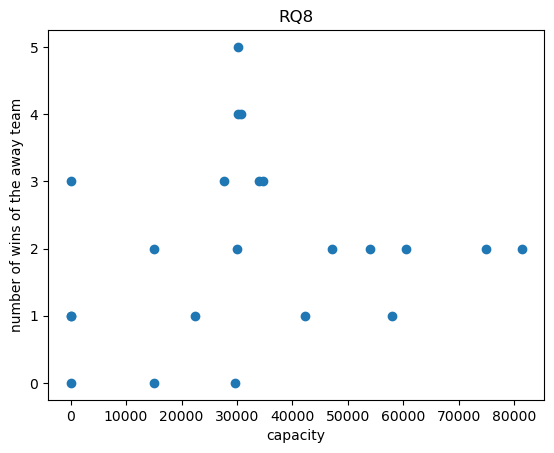

In [127]:
x = result[4]
y = result[1]
plt.scatter(x,y)
plt.title('RQ8')
plt.xlabel('capacity')
plt.ylabel('number of wins of the away team')
plt.show()

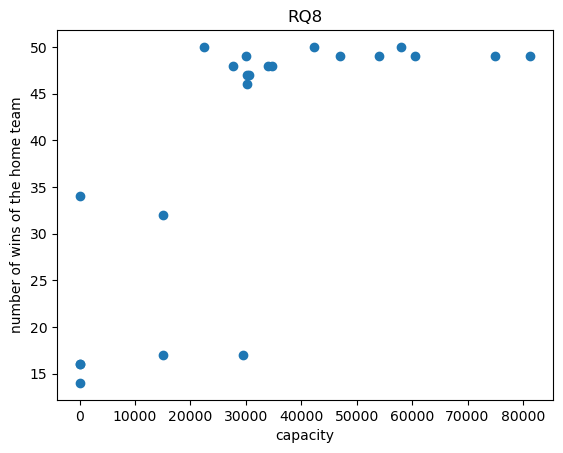

In [129]:
x = result[4]
y = result[2]
plt.scatter(x,y)
plt.title('RQ8')
plt.xlabel('capacity')
plt.ylabel('number of wins of the home team')
plt.show()